<a href="https://colab.research.google.com/github/mdrehantabish123/mdrehantabish123-Data_Science_Lab_SE_A_38/blob/main/experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview:
   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


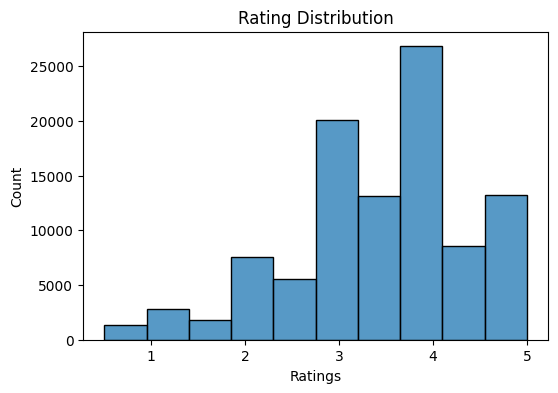


RMSE: 0.9652945690141774

Accuracy: 0.6586671955573186

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.51      0.54      7829
           1       0.71      0.75      0.73     12339

    accuracy                           0.66     20168
   macro avg       0.64      0.63      0.63     20168
weighted avg       0.65      0.66      0.65     20168



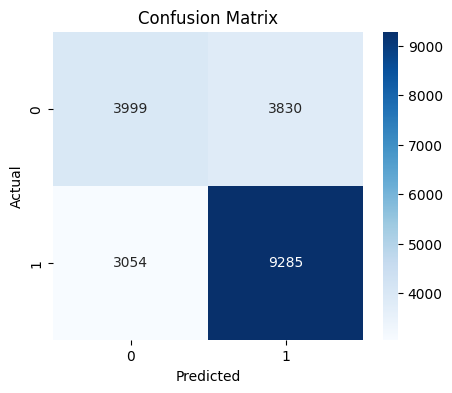

In [15]:
# ================= STEP 1: Import Libraries =================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix


# ================= STEP 2: Load Dataset =================
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

data = pd.merge(ratings, movies, on="movieId")

print("Dataset Preview:")
print(data.head())


# ================= STEP 3: Data Visualization =================
plt.figure(figsize=(6,4))
sns.histplot(data['rating'], bins=10)
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()


# ================= STEP 4: Preprocessing =================
data['genres'] = data['genres'].astype('category').cat.codes

X = data[['userId', 'movieId', 'genres']]
y_reg = data['rating']


# ================= STEP 5: Train-Test Split =================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)


# ================= STEP 6: Train Regression Model =================
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)


# ================= STEP 7: Evaluate Regression =================
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("\nRMSE:", rmse)


# ================= STEP 8: Convert to Classification =================
data['rating_class'] = np.where(data['rating'] >= 3.5, 1, 0)
y_cls = data['rating_class']


# ================= STEP 9: Train Classification Model =================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred_cls = clf.predict(X_test)


# ================= STEP 10: Evaluate Classification =================
print("\nAccuracy:", accuracy_score(y_test, y_pred_cls))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cls))


# ================= STEP 11: Confusion Matrix =================
cm = confusion_matrix(y_test, y_pred_cls)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()